In [1]:
%pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 209.8 kB/s  0:01:03m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 173.0 kB/s  0:01:17m0:00:0100:04
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Scikit Learn

Scikit Learn is a library in Python that provides simple and efficient tools for data mining and data analysis. It is built on top of NumPy, SciPy, and matplotlib, and is designed to work seamlessly with these libraries.

In [3]:
import sklearn
import pandas as pd

# Intro to Machine Learning

### Regression and Classification

-> Regression is a type of supervised machine learning algorithm that is used to predict a continuous target variable based on one or more input features. It establishes a relationship between the dependent variable (target) and independent variables (features) by fitting a line or curve to the data points.

-> Classification is a supervised learning technique that is used to predict the categorical class labels of new instances, based on past observations. It involves training a model on a labeled dataset, where the input features are associated with known output classes. The goal of classification is to assign new instances to one of the predefined classes based on their feature values.

In [5]:
df = pd.read_csv('/Users/aareev/VS-Code/Vedam/Vedam Semester 3/Python(ML) Sem 3/Data/Titanic-Dataset.csv')
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
# Drop unusable columns
df = df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'])

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop rows where Embarked is missing
df = df.dropna(subset=['Embarked'])

# Check cleaned dataset
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Linear Regression

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
df = pd.read_csv('/Users/aareev/VS-Code/Vedam/Vedam Semester 3/Python(ML) Sem 3/Data/mpg.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [4]:
df = df.drop(columns=['name', 'origin'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print(df.shape, "|", df.isna().sum().sum(), "missing")
df.head()

(398, 7) | 0 missing


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [5]:
X = df.drop(columns='mpg')
y = df['mpg']
print(X.shape, y.shape)

(398, 6) (398,)


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

print(X_train.shape, X_test.shape)

(318, 6) (80, 6)


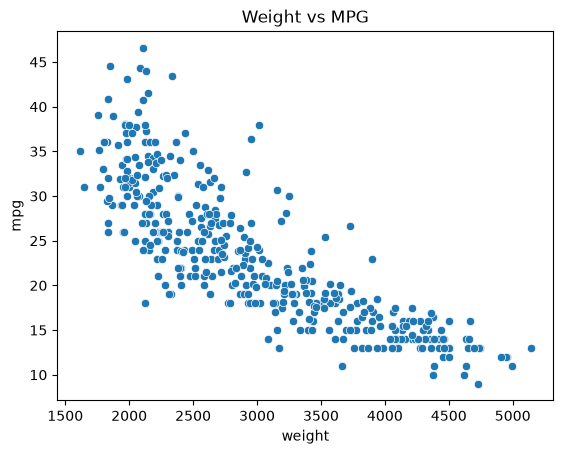

In [3]:
sns.scatterplot(data = df, x = 'weight', y ='mpg')
plt.title("Weight vs MPG")
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train[['weight']], y_train)
print("coef:   ", model.coef_)
print("intercept:", model.intercept_)

coef:    [-0.00780524]
intercept: 46.78206336645047


In [8]:
print(model.score(X_test[['weight']], y_test)) # r2 score 

0.722971057303075


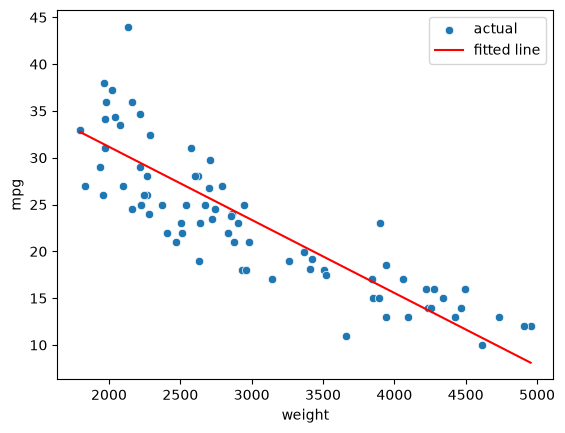

In [9]:
sns.scatterplot(x=X_test['weight'], y=y_test, label='actual')
sns.lineplot(x=X_test['weight'], y=model.predict(X_test[['weight']]),
             color='red', label='fitted line')
plt.show()

In [12]:
model_all = LinearRegression()
model_all.fit(X_train, y_train)
print(model_all.score(X_test, y_test))

0.8244245330943358


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model_all.predict(X_test)

print("MAE: ", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:  ", r2_score(y_test, y_pred))

MAE:  2.466780800452033
RMSE: 3.0724694408998414
R2:   0.8244245330943358


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_trained_scaled.shape, X_test_scaled.shape)

(318, 6) (80, 6)


In [15]:
pd.DataFrame({
    'feature': X_train.columns,
    'coef without scaling': model_all.coef_.round(3),
    'coef with scaling': model_all.coef_.round(3)
})

,feature,coef without scaling,coef with scaling
0,cylinders,0.069,0.069
1,displacement,0.002,0.002
2,horsepower,0.003,0.003
3,weight,-0.007,-0.007
4,acceleration,0.081,0.081
5,model_year,0.801,0.801


### K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a simple, intuitive, and popular supervised machine learning algorithm used for both classification (predicting a category) and regression (predicting a continuous value).

In [16]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()

knn.fit(X_train, y_train)
acc_knn_raw = knn.score(X_test, y_test)
print("Accuracy of KNN without scaling:", acc_knn_raw)

Accuracy of KNN without scaling: 0.7659996807953288


In [18]:
knn_scaled = KNeighborsRegressor()
knn_scaled.fit(X_trained_scaled, y_train)
acc_knn_scaled = knn_scaled.score(X_test_scaled, y_test)
print("Accuracy of KNN with scaling:", acc_knn_scaled)

Accuracy of KNN with scaling: 0.8785489694954951


In [19]:
pd.DataFrame({
    'model': ['Linear Regression',
              'kNN Regressor (no scaling)',
              'kNN Regressor (with scaling)'],
    'R2': [round(model_all.score(X_test, y_test), 4),
           round(acc_knn_raw, 4),
           round(acc_knn_scaled, 4)]
})

,model,R2
0,Linear Regression,0.8244
1,kNN Regressor (no scaling),0.7660
2,kNN Regressor (with scaling),0.8785


In [20]:
df = pd.read_csv('/Users/aareev/VS-Code/Vedam/Vedam Semester 3/Python(ML) Sem 3/Data/Titanic-Dataset.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [21]:
df = df.drop(columns=['Name', 'PassengerId', 'Embarked'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
print(df.shape, "|", df.isna().sum().sum(), "missing")
df.head()

(891, 9) | 687 missing


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
0,0,3,0,22.0,1,0,A/5 21171,7.2500,NaN
1,1,1,1,38.0,1,0,PC 17599,71.2833,C85
2,1,3,1,26.0,0,0,STON/O2. 3101282,7.9250,NaN
3,1,1,1,35.0,1,0,113803,53.1000,C123
4,0,3,0,35.0,0,0,373450,8.0500,NaN


In [22]:
x = df.drop(columns='Survived')
y = df['Survived']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(712, 8) (179, 8) (712,) (179,)


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:15])

ValueError: could not convert string to float: 'PC 17483'